## Gene-wise spatial negative-binomial model

### Current analysis scope

The gene-expression notebook reads the data containing both `pred_region` and `pred_celltype`. In the current implementation, it subsets the data to slice `A6` before fitting the gene-expression models. Therefore, the resulting simulated expression matrix corresponds only to the cells in slice `A6`, not to all 12 slices.

For spot or cell $i=1,\ldots,n$ in this slice and gene $g$, let $Y_{ig}$ denote the observed count from `adata.layers["counts"]`. Before fitting, each count vector is converted to a dense array, rounded to the nearest integer, cast to an integer type, and truncated below at zero.

Let $L_i$ denote the library size value read from `adata.obs["size"]`, let $\widehat C_i$ denote `pred_celltype`, and let $\widehat D_i$ denote `pred_region`. The code sets

$$
L_i^{+}=\max(L_i,10^{-8})
$$

and uses $\log L_i^{+}$ as an offset.

The single-gene diagnostic call uses `use_3d=True`. However, the loop that fits and simulates all genes calls `fit_one_gene` with `use_3d=False`. Consequently, the actual all-gene simulation uses only $(x_i,y_i)$ to construct the spatial basis. The $z_i$ coordinate is not included in the fitted spatial basis in that loop.

### Observation model

The implemented count model is the NB parameterization

$$
Y_{ig}\mid\mu_{ig},\alpha_g
\sim
\operatorname{NB}(\mu_{ig},\alpha_g),
$$

with probability mass function

$$
P(Y_{ig}=y\mid\mu_{ig},\alpha_g)
=
\frac{\Gamma(y+\alpha_g^{-1})}
{\Gamma(\alpha_g^{-1})\Gamma(y+1)}
\left(\frac{1}{1+\alpha_g\mu_{ig}}\right)^{\alpha_g^{-1}}
\left(\frac{\alpha_g\mu_{ig}}{1+\alpha_g\mu_{ig}}\right)^y,
\qquad y=0,1,2,\ldots.
$$

Its conditional mean and variance are

$$
\mathbb{E}(Y_{ig}\mid\mu_{ig},\alpha_g)=\mu_{ig},
$$

and

$$
\operatorname{Var}(Y_{ig}\mid\mu_{ig},\alpha_g)
=
\mu_{ig}+\alpha_g\mu_{ig}^2.
$$

### Biological design matrix

For each gene, the biological design matrix contains an intercept, coefficients for the sampled cell-type labels, and coefficients for the predicted domain labels. Cell type and domain are encoded separately using `pandas.get_dummies(..., drop_first=True)`. For each categorical variable, the dummy column corresponding to its first category is omitted to avoid collinearity with the intercept. The omitted cell-type and domain categories are denoted by $c_0$ and $d_0$, respectively, and serve as the reference levels for interpreting the regression coefficients. Then

$$
\boldsymbol{X}_i^\top\boldsymbol{\beta}_g
=
\beta_{0g}
+
\sum_{c\neq c_0}
\beta_{gc}^{\mathrm{cell}}
\mathbf{1}\{\widehat C_i=c\}
+
\sum_{d\neq d_0}
\beta_{gd}^{\mathrm{domain}}
\mathbf{1}\{\widehat D_i=d\}.
$$

The model therefore conditions on the simulated cell-type label and the coordinate-network domain prediction as fixed categorical covariates. 

### Spatial radial-basis representation

Let $\boldsymbol{w}_i=(x_i,y_i)^\top$ for the all-gene simulation. More generally, the function can use $\boldsymbol{w}_i=(x_i,y_i,z_i)^\top$ when `use_3d=True`. Each selected coordinate dimension is standardized as

$$
\widetilde w_{iq}
=
\frac{w_{iq}-\overline w_q}{s_q+10^{-8}},
$$

where $\overline w_q$ and $s_q$ are the empirical mean and standard deviation computed within the selected slice.

The default number of basis functions is $K_B=30$, truncated to $\min(30,n)$ if fewer than 30 observations are available. When $K_B<n$, `MiniBatchKMeans` is applied to the standardized coordinates using random state 123, batch size $\min(1024,n)$, and `n_init="auto"`. Let $\boldsymbol{a}_1,\ldots,\boldsymbol{a}_{K_B}$ denote the resulting centers. If $K_B=n$, the standardized observed coordinates themselves are used as centers.

The bandwidth is the median of all strictly positive pairwise Euclidean distances between the centers:

$$
h
=
\operatorname{median}
\left\{
\|\boldsymbol{a}_k-\boldsymbol{a}_{\ell}\|_2:
1\leq k<\ell\leq K_B,
\ \|\boldsymbol{a}_k-\boldsymbol{a}_{\ell}\|_2>0
\right\}.
$$

If no positive center distance is available, $h$ is set to 1, and the final value is truncated below at $10^{-6}$. The $k$th radial-basis function is

$$
B_k(\boldsymbol{w}_i)
=
\exp\left\{
-\frac{1}{2}
\frac{\|\widetilde{\boldsymbol{w}}_i-\boldsymbol{a}_k\|_2^2}{h^2}
\right\}.
$$

Let

$$
\boldsymbol{B}(\boldsymbol{w}_i)
=
\left(
B_1(\boldsymbol{w}_i),\ldots,B_{K_B}(\boldsymbol{w}_i)
\right)^\top.
$$

The log-mean model is

$$
\log\mu_{ig}
=
\log L_i^{+}
+
\boldsymbol{X}_i^\top\boldsymbol{\beta}_g
+
\boldsymbol{B}(\boldsymbol{w}_i)^\top\boldsymbol{\gamma}_g.
$$

This is a fixed-basis spatial negative-binomial GLM. It is not a latent Gaussian-process model, and no Matérn covariance or spatial random effect is estimated.

### Gene-wise fitting procedure

For each gene, the code first fits a Poisson GLM with the same design matrix, spatial basis, and offset. Let $\widehat\mu_{ig}^{(0)}$ denote the fitted Poisson mean, truncated below at $10^{-8}$. The method-of-moments estimator of the NB overdispersion is

$$
\widetilde\alpha_g
=
\frac{
\sum_{i=1}^{n}
\left\{
(Y_{ig}-\widehat\mu_{ig}^{(0)})^2
-\widehat\mu_{ig}^{(0)}
\right\}
}
{
\sum_{i=1}^{n}
(\widehat\mu_{ig}^{(0)})^2
}.
$$

The implemented estimate is

$$
\widehat\alpha_g
=
\min\left\{
100,
\max\left(10^{-8},\widetilde\alpha_g\right)
\right\}.
$$

Given this fixed value of $\widehat\alpha_g$, a negative-binomial GLM is fitted with `statsmodels.GLM` to estimate the regression and spatial-basis coefficients. Thus, the code does not jointly maximize the likelihood over $\alpha_g$, $\boldsymbol{\beta}_g$, and $\boldsymbol{\gamma}_g$. It estimates $\alpha_g$ by the Poisson-based moment formula and then fits the GLM coefficients conditionally on that estimate.

The Poisson fit uses at most 50 iterations, and the negative-binomial fit uses at most 100 iterations.

### Count simulation

Let $\widehat{\boldsymbol{\beta}}_g$ and $\widehat{\boldsymbol{\gamma}}_g$ denote the fitted coefficients. The untruncated fitted linear predictor is

$$
\widehat\eta_{ig}
=
\log L_i^{+}
+
\boldsymbol{X}_i^\top\widehat{\boldsymbol{\beta}}_g
+
\boldsymbol{B}(\boldsymbol{w}_i)^\top\widehat{\boldsymbol{\gamma}}_g.
$$

Before exponentiation, the implementation truncates it to

$$
\widehat\eta_{ig}^{\mathrm{clip}}
=
\min\left\{
20,
\max(-20,\widehat\eta_{ig})
\right\},
$$

and sets

$$
\widehat\mu_{ig}
=
\exp\left(\widehat\eta_{ig}^{\mathrm{clip}}\right).
$$

The SciPy negative-binomial parameters are

$$
\widehat r_g
=
\frac{1}{\max(\widehat\alpha_g,10^{-8})},
$$

and

$$
\widehat p_{ig}
=
\frac{\widehat r_g}{\widehat r_g+\widehat\mu_{ig}}.
$$

The simulated count is generated as

$$
Y_{ig}^{\mathrm{sim}}
\sim
\operatorname{NB}
\left(
\widehat r_g,\widehat p_{ig}
\right),
$$

where SciPy uses $\widehat r_g$ as the size parameter and $\widehat p_{ig}$ as the success probability.

The all-gene loop calls the simulation function with seed 123 separately for every gene. Consequently, each gene simulation reinitializes a NumPy random-number generator with the same seed. This guarantees reproducibility, but it also means that different genes use the same underlying pseudorandom-number sequence positions rather than independent generator streams.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import nbinom
from sklearn.cluster import MiniBatchKMeans


# ===============================
# Construct design matrix: cell type + domain
# ===============================
def build_design_matrix(meta):
    ct = pd.get_dummies(meta["cell_type"], drop_first=True)
    dom = pd.get_dummies(meta["domain"], drop_first=True)

    X = pd.concat([
        pd.Series(1.0, index=meta.index, name="Intercept"),
        ct,
        dom
    ], axis=1)

    return X.astype(float)


# ===============================
# Construct spatial RBF basis
#    This replaces the GPBoost latent GP by a fast spatial NB-GLM:
#    log(mu_i) = offset_i + X_i beta + B(s_i) gamma
# ===============================
def make_spatial_basis(coords, n_basis=30, random_state=123):
    coords = np.asarray(coords, dtype=np.float64)
    coords = (coords - coords.mean(axis=0)) / (coords.std(axis=0) + 1e-8)

    n = coords.shape[0]
    n_basis = min(n_basis, n)

    if n_basis < n:
        km = MiniBatchKMeans(
            n_clusters=n_basis,
            random_state=random_state,
            batch_size=min(1024, n),
            n_init="auto"
        )
        centers = km.fit(coords).cluster_centers_
    else:
        centers = coords.copy()

    d2 = np.sum((coords[:, None, :] - centers[None, :, :]) ** 2, axis=2)

    center_dist = np.sqrt(
        np.sum((centers[:, None, :] - centers[None, :, :]) ** 2, axis=2)
    )
    positive_dist = center_dist[center_dist > 0]
    bandwidth = np.median(positive_dist) if positive_dist.size > 0 else 1.0
    bandwidth = max(float(bandwidth), 1e-6)

    B = np.exp(-0.5 * d2 / bandwidth**2)
    B = pd.DataFrame(
        B,
        index=None,
        columns=[f"spatial_rbf_{k+1}" for k in range(n_basis)]
    )
    return B.astype(float), coords


# ===============================
# Fit for one gene: statsmodels spatial NB-GLM
# ===============================
def fit_one_gene(y, meta, use_3d=False, n_spatial_basis=30):

    print("  [fit_one_gene] entered", flush=True)

    # ===============================
    # Coordinates
    # ===============================
    if use_3d:
        coords_raw = meta[["x", "y", "z"]].values
    else:
        coords_raw = meta[["x", "y"]].values

    B, coords = make_spatial_basis(
        coords_raw,
        n_basis=n_spatial_basis,
        random_state=123
    )

    print(
        "  [fit_one_gene] spatial basis ready:",
        B.shape,
        flush=True
    )

    # ===============================
    # Design matrix = biological covariates + spatial basis
    # ===============================
    X_base = build_design_matrix(meta).reset_index(drop=True)
    X = pd.concat([X_base, B.reset_index(drop=True)], axis=1)
    X_np = np.asarray(X.values, dtype=np.float64)

    print(
        "  [fit_one_gene] X ready:",
        X_np.shape,
        X_np.dtype,
        flush=True
    )

    # ===============================
    # offset
    # ===============================
    libsize = np.maximum(meta["library_size"].values, 1e-8)
    offset = np.log(libsize).astype(np.float64)

    # ===============================
    # y
    # ===============================
    y = np.asarray(y, dtype=np.float64)
    y[y < 0] = 0

    nonzero = np.count_nonzero(y)
    y_var = np.var(y)

    print(
        "  [fit_one_gene] y summary:",
        "sum =", float(y.sum()),
        "nonzero =", int(nonzero),
        "zero_prop =", float(np.mean(y == 0)),
        "max =", float(y.max()),
        "var =", float(y_var),
        flush=True
    )

    if nonzero < 10 or y_var < 1e-12:
        raise ValueError(
            f"Gene too sparse or constant for spatial NB-GLM fitting: "
            f"nonzero={nonzero}, var={y_var}"
        )

    # ===============================
    # First fit a Poisson GLM to obtain the moment-based estimate of alpha, then fit the NB2 GLM
    #    Var(Y_i | mu_i) = mu_i + alpha * mu_i^2
    # ===============================
    print("  [fit_one_gene] before statsmodels GLM fit", flush=True)

    pois_fit = sm.GLM(
        y,
        X_np,
        family=sm.families.Poisson(),
        offset=offset
    ).fit(maxiter=50, disp=0)

    mu0 = np.maximum(pois_fit.fittedvalues, 1e-8)
    alpha = np.sum((y - mu0) ** 2 - mu0) / np.sum(mu0 ** 2)
    alpha = float(np.clip(alpha, 1e-8, 100.0))

    nb_fit = sm.GLM(
        y,
        X_np,
        family=sm.families.NegativeBinomial(alpha=alpha),
        offset=offset
    ).fit(maxiter=100, disp=0)

    print("  [fit_one_gene] statsmodels NB-GLM fit finished", flush=True)
    print("  [fit_one_gene] alpha =", alpha, flush=True)

    beta = np.asarray(nb_fit.params, dtype=np.float64)

    return {
        "beta": beta,
        "X_columns": X.columns,
        "alpha": alpha,
        "coords": coords,
        "X": X,
        "offset": offset,
        "model": nb_fit
    }


# ===============================
# Simulate for one gene
# ===============================
def simulate_one_gene(fit_result, seed=123):

    rng = np.random.default_rng(seed)

    beta = fit_result["beta"]
    X = fit_result["X"].values
    alpha = fit_result["alpha"]
    offset = fit_result["offset"]

    eta = X @ beta + offset
    eta = np.clip(eta, -20, 20)
    mu = np.exp(eta)

    # statsmodels NB2: Var(Y|mu)=mu+alpha*mu^2
    # scipy nbinom parameterization: size=1/alpha, p=size/(size+mu)
    r = 1.0 / max(alpha, 1e-8)
    p = r / (r + mu)
    y_sim = nbinom(n=r, p=p).rvs(random_state=rng)

    return np.asarray(y_sim, dtype=int)


In [2]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

adata = sc.read("../adata_backup_with_pred_region_celltype.h5ad")
adata

AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'slices', 'Coord_X', 'Coord_Y', 'x', 'y', 'z', 'cell_type', 'batch', 'n_genes', 'size', 'STAIR', 'pred_region', 'pred_celltype'
    var: 'n_cells'
    uns: 'batch_colors', 'cell_type_colors', 'log1p', 'pred_celltype_names'
    obsm: 'STAIR', 'STAIR_clean', 'XYZ_rel_pca_global', 'latent', 'pred_celltype_proba', 'spatial', 'spatial_2d_raw', 'spatial_2d_raw_rotate', 'spatial_2d_μm', 'spatial_2d_μm_rotate', 'spatial_3d', 'spatial_3d_raw', 'spatial_3d_raw_rotate', 'spatial_3d_μm', 'spatial_3d_μm_rotate'
    layers: 'Denoise', 'counts', 'noise1', 'noise2', 'noise3', 'noise4'

In [3]:
region_key = "pred_region"
celltype_key = "pred_celltype"

# Select one slice
adata_slice = adata[adata.obs["batch"] == "A6"].copy()

# Construct meta
meta = pd.DataFrame({
    "x": adata_slice.obs["x"].values,
    "y": adata_slice.obs["y"].values,
    "z": adata_slice.obs["z"].values,
    "cell_type": adata_slice.obs[celltype_key].astype(str).values,
    "domain": adata_slice.obs[region_key].astype(str).values,
    "library_size": adata_slice.obs["size"].values
}, index=adata_slice.obs_names)

print("pred_region" in adata.obs.columns)
print("pred_celltype" in adata.obs.columns)

print(adata.obs[["pred_region", "pred_celltype"]].head())

True
True
                                     pred_region pred_celltype
Cell_ID                                                       
6749ccb4-2ed1-4029-968f-820a287f43c8         6.0    Inhibitory
6cac74bd-4ea7-4701-8701-42563cc65eb8         6.0    Inhibitory
9f29bd57-16a5-4b26-b9f5-37598809da9e         6.0    Inhibitory
d7eb4e0b-276e-47e3-a55c-0b033180a2fe         8.0     OD Mature
54434f3a-eba9-4aec-af35-c9d317ffa1d5         6.0     Astrocyte


In [4]:
print(adata_slice.n_obs)
print(adata_slice.n_vars)

5488
155


In [5]:
import psutil, os, gc, time
import numpy as np

process = psutil.Process(os.getpid())

def mem_gb():
    return process.memory_info().rss / 1024**3

gene = adata_slice.var_names[0]

print("Gene:", gene)
print("Initial memory:", mem_gb(), "GB")

y = adata_slice[:, gene].layers["counts"].toarray().ravel()
y = np.round(y).astype(int)
y[y < 0] = 0

print("After loading y:", mem_gb(), "GB")

print("Before fitting", flush=True)

fit_result = fit_one_gene(
    y=y,
    meta=meta,
    use_3d=True
)

print("After fitting, before simulation", flush=True)

y_sim = simulate_one_gene(
    fit_result,
    seed=123
)

print("After simulation", flush=True)

Gene: Ace2
Initial memory: 0.840728759765625 GB
After loading y: 0.840911865234375 GB
Before fitting
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 1255.0 nonzero = 694 zero_prop = 0.8735422740524781 max = 17.0 var = 0.9682954899212913
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 9.236505922009679
After fitting, before simulation
After simulation


In [6]:
# ===============================
# Fit, simulate, and save all A6 gene models compactly
# ===============================
from pathlib import Path
import pickle

MODEL_DIR = Path("../saved_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
GENE_FITS_PATH = MODEL_DIR / "gene_fit_results_A6.pkl"

all_sim_expr = []
gene_names = adata_slice.var_names.astype(str).tolist()
gene_fits, failed_genes = {}, {}
shared_X = shared_offset = shared_X_columns = None

for i, gene in enumerate(gene_names):
    print(f"\nProcessing gene {i+1}/{len(gene_names)}: {gene}")
    try:
        y = adata_slice[:, gene].layers["counts"].toarray().ravel()
        y = np.maximum(np.round(y).astype(int), 0)

        fit_result = fit_one_gene(y=y, meta=meta, use_3d=False)
        y_sim = simulate_one_gene(fit_result, seed=123)
        all_sim_expr.append(y_sim)

        if shared_X is None:
            shared_X = np.asarray(fit_result["X"], dtype=np.float64)
            shared_offset = np.asarray(fit_result["offset"], dtype=np.float64)
            shared_X_columns = list(map(str, fit_result["X_columns"]))
        gene_fits[gene] = {
            "beta": np.asarray(fit_result["beta"], dtype=np.float64),
            "alpha": float(fit_result["alpha"])
        }

    except Exception as e:
        print(f"[ERROR] {gene} failed: {e}")
        failed_genes[gene] = repr(e)
        all_sim_expr.append(np.zeros(adata_slice.n_obs, dtype=int))

sim_expr = np.asarray(all_sim_expr, dtype=np.int32).T

bundle = {
    "format_version": 2,
    "slice_id": "A6",
    "obs_names": adata_slice.obs_names.astype(str).tolist(),
    "genes": gene_names,
    "X": shared_X,
    "X_columns": shared_X_columns,
    "offset": shared_offset,
    "fits": gene_fits,
    "failed_genes": failed_genes,
    "use_3d": False,
    "n_spatial_basis": 30
}
with open(GENE_FITS_PATH, "wb") as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Simulation matrix:", sim_expr.shape)
print(f"Successful fits: {len(gene_fits)}/{len(gene_names)}")
print("Saved gene models to", GENE_FITS_PATH.resolve())



Processing gene 1/155: Ace2
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 1255.0 nonzero = 694 zero_prop = 0.8735422740524781 max = 17.0 var = 0.9682954899212913
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 9.236505922009679

Processing gene 2/155: Adora2a
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 1512.0 nonzero = 828 zero_prop = 0.8491253644314869 max = 15.0 var = 1.030872553102874
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 8.531235594001867

Processing gene 3/155: Aldh1l1
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 1

  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 18480.0 nonzero = 3363 zero_prop = 0.38720845481049565 max = 102.0 var = 50.83407955018741
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 0.6485323567499314

Processing gene 22/155: Cdkn1a
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 7342.0 nonzero = 2902 zero_prop = 0.4712099125364432 max = 37.0 var = 5.82246117157817
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 2.1625739115104072

Processing gene 23/155: Cenpe
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 2160.0 nonzero = 1534 zero_prop = 0.720481049562682

  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 9560.0 nonzero = 1357 zero_prop = 0.7527332361516035 max = 77.0 var = 40.34304796470858
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 2.0079136732044396

Processing gene 42/155: Esr1
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 19820.0 nonzero = 2611 zero_prop = 0.5242346938775511 max = 49.0 var = 42.23100440717729
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 0.8423559608130777

Processing gene 43/155: Etv1
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 6106.0 nonzero = 2496 zero_prop = 0.5451895043731778 max = 36.0 var = 5.136736048542699
  [fit_one_gene]

  [fit_one_gene] y summary: sum = 7681.0 nonzero = 2244 zero_prop = 0.5911078717201166 max = 28.0 var = 7.451289926763083
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 2.0043028698884453

Processing gene 62/155: Igf1r
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 25530.0 nonzero = 4635 zero_prop = 0.15543002915451895 max = 120.0 var = 53.826759975647896
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 2.055655442943193

Processing gene 63/155: Igf2r
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 10529.0 nonzero = 3753 zero_prop = 0.3161443148688047 max = 23.0 var = 4.251201103228671
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_g

  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 9.629662881502327

Processing gene 82/155: Npy1r
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 5571.0 nonzero = 2592 zero_prop = 0.5276967930029155 max = 28.0 var = 3.1256823461631638
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 1.7087211365032777

Processing gene 83/155: Npy2r
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 14149.0 nonzero = 3038 zero_prop = 0.44642857142857145 max = 42.0 var = 22.386017644380743
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 1.8103668395112094

Processing gene 84/155: Ntng1
  [fit_one_

...

  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 14.28877423995991

Processing gene 140/155: Gal
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 113.0 nonzero = 102 zero_prop = 0.9814139941690962 max = 3.0 var = 0.024539593143588133
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 1.9675244690364582

Processing gene 141/155: Gnrh1
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 4.0 nonzero = 3 zero_prop = 0.9994533527696793 max = 2.0 var = 0.0010927632194068797
[ERROR] Gnrh1 failed: Gene too sparse or constant for spatial NB-GLM fitting: nonzero=3, var=0.0010927632194068797

Processing gene 142/155: Mbp
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_

/opt/anaconda3/envs/STAIR-env/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1402: RuntimeWarning: invalid value encountered in divide
  endog_mu = self._clean(endog / mu)


  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 1e-08

Processing gene 144/155: Nts
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 38.0 nonzero = 38 zero_prop = 0.9930758017492711 max = 1.0 var = 0.006876253729313467
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 1e-08

Processing gene 145/155: Oxt
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 281.0 nonzero = 45 zero_prop = 0.9918002915451894 max = 19.0 var = 0.5879395157948644
  [fit_one_gene] before statsmodels GLM fit
[ERROR] Oxt failed: NaN, inf or invalid value detected in weights, estimation infeasible.

Processing gene 146/155: Penk
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X 

/opt/anaconda3/envs/STAIR-env/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:527: RuntimeWarning: overflow encountered in exp
  return np.exp(z)
/opt/anaconda3/envs/STAIR-env/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:445: RuntimeWarning: invalid value encountered in divide
  endog_mu = self._clean(endog / mu)
/opt/anaconda3/envs/STAIR-env/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:447: RuntimeWarning: overflow encountered in multiply
  return 2 * resid_dev
/opt/anaconda3/envs/STAIR-env/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:143: RuntimeWarning: invalid value encountered in multiply
  return 1. / (self.link.deriv(mu)**2 * self.variance(mu))
/opt/anaconda3/envs/STAIR-env/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:143: RuntimeWarning: divide by zero encountered in divide
  return 1. / (self.link.deriv(mu)**2 * self.variance(mu))
/opt/anaconda3/envs/STAIR-env/lib/python3.

  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 1.9970426736440052

Processing gene 147/155: Scg2
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 401.0 nonzero = 373 zero_prop = 0.932033527696793 max = 3.0 var = 0.07902688160332855
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 1e-08

Processing gene 148/155: Sln
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene] X ready: (5488, 51) float64
  [fit_one_gene] y summary: sum = 652.0 nonzero = 647 zero_prop = 0.8821064139941691 max = 2.0 var = 0.10651227379748235
  [fit_one_gene] before statsmodels GLM fit
  [fit_one_gene] statsmodels NB-GLM fit finished
  [fit_one_gene] alpha = 1e-08

Processing gene 149/155: Sst
  [fit_one_gene] entered
  [fit_one_gene] spatial basis ready: (5488, 30)
  [fit_one_gene

      gene   moran_I  true_nonzero  sim_nonzero
142   Nnat  0.586223          2073          101
141    Mbp  0.504370          1192          409
147    Sln  0.478732          2448          533
41    Esr1  0.397844          2686         3391
20   Cd24a  0.352309          3446         3823
63    Irs4  0.343976          4015         4544
38    Ebf3  0.272444           546          612
53     Gda  0.270396          3173         3764
93    Pak3  0.265055          4806         5234
40    Ermn  0.259933          1528         2067
Selected genes: ['Ebf3', 'Pak3', 'Ermn']


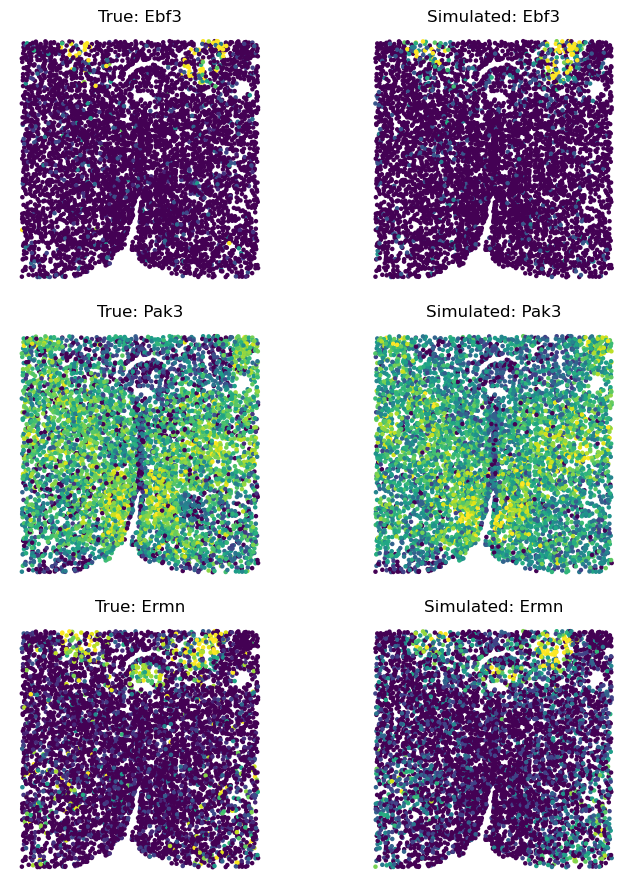

In [7]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===============================
# 1. Get true count matrix
# ===============================
Y_true = adata_slice.layers["counts"]
if hasattr(Y_true, "toarray"):
    Y_true = Y_true.toarray()
Y_true = np.asarray(Y_true)

# ===============================
# 2. Build 3D kNN graph for Moran's I
# ===============================
coords = meta[["x", "y", "z"]].values.astype(float)
coords = (coords - coords.mean(axis=0)) / (coords.std(axis=0) + 1e-8)

k = 15
nn = NearestNeighbors(n_neighbors=k + 1).fit(coords)
neighbors = nn.kneighbors(coords, return_distance=False)[:, 1:]

def moran_i(x, neighbors):
    x = np.log1p(np.asarray(x, dtype=float))
    z = x - x.mean()
    denom = np.sum(z ** 2)
    if denom <= 0:
        return np.nan
    n = len(x)
    num = np.sum(z[:, None] * z[neighbors])
    return (n / (n * k)) * num / denom

# ===============================
# 3. Select top 3 SVG-like genes
# ===============================
moran_vals = []
for j, g in enumerate(gene_names):
    moran_vals.append(moran_i(Y_true[:, j], neighbors))

svg_df = pd.DataFrame({
    "gene": gene_names,
    "moran_I": moran_vals,
    "true_nonzero": (Y_true > 0).sum(axis=0),
    "sim_nonzero": (sim_expr > 0).sum(axis=0)
})

svg_df = svg_df.sort_values("moran_I", ascending=False)

selected_genes = svg_df.query(
    "true_nonzero >= 30 and sim_nonzero >= 10"
).head(3)["gene"].tolist()


# selected_genes = ['Nnat', 'Mbp', 'Sln']
# selected_genes = ['Cd24a', 'Irs4', 'Gda']
selected_genes = ['Ebf3', 'Pak3', 'Ermn']

print(svg_df.head(10))
print("Selected genes:", selected_genes)

# ===============================
# 4. Plot true vs simulated expression heatmaps
# ===============================
x = meta["x"].values
y = meta["y"].values

fig, axes = plt.subplots(
    len(selected_genes), 2,
    figsize=(8, 3 * len(selected_genes))
)

if len(selected_genes) == 1:
    axes = np.array([axes])

for r, gene in enumerate(selected_genes):
    j = gene_names.index(gene)

    true_expr = np.log1p(Y_true[:, j])
    sim_expr_g = np.log1p(sim_expr[:, j])

    vmax = np.percentile(
        np.concatenate([true_expr, sim_expr_g]),
        99
    )

    axes[r, 0].scatter(x, y, c=true_expr, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[r, 0].set_title(f"True: {gene}")
    axes[r, 0].set_aspect("equal")
    axes[r, 0].axis("off")

    axes[r, 1].scatter(x, y, c=sim_expr_g, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[r, 1].set_title(f"Simulated: {gene}")
    axes[r, 1].set_aspect("equal")
    axes[r, 1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
selected_genes

['Ebf3', 'Pak3', 'Ermn']

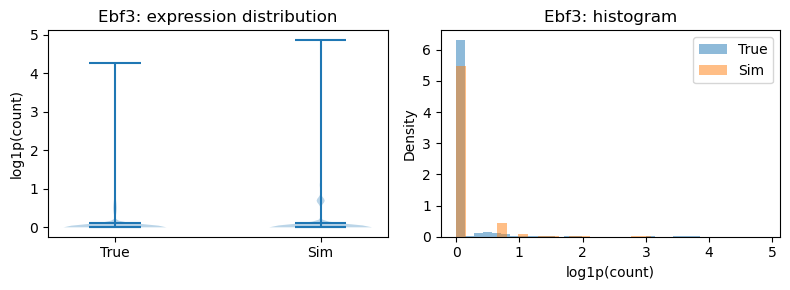

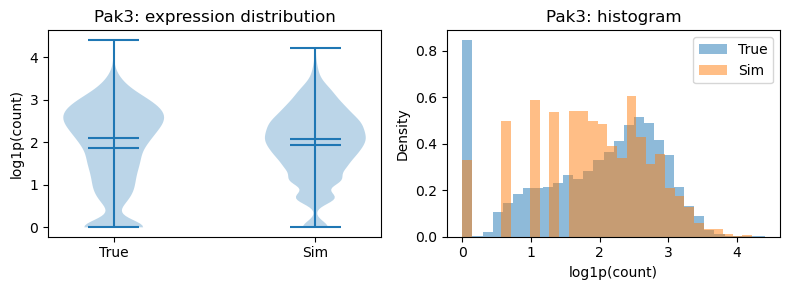

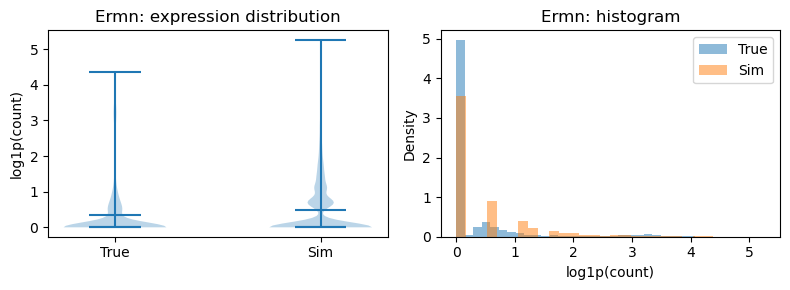

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# selected_genes should already exist from the SVG selection step
# Y_true: cells x genes observed count matrix
# sim_expr: cells x genes simulated count matrix
# gene_names: list of gene names

for gene in selected_genes:
    j = gene_names.index(gene)

    true_g = np.log1p(Y_true[:, j])
    sim_g = np.log1p(sim_expr[:, j])

    df_g = pd.DataFrame({
        "Expression": np.concatenate([true_g, sim_g]),
        "Data": ["True"] * len(true_g) + ["Simulated"] * len(sim_g)
    })

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    # Violin plot
    axes[0].violinplot(
        [true_g, sim_g],
        showmeans=True,
        showmedians=True
    )
    axes[0].set_xticks([1, 2])
    axes[0].set_xticklabels(["True", "Sim"])
    axes[0].set_title(f"{gene}: expression distribution")
    axes[0].set_ylabel("log1p(count)")

    # Histogram
    axes[1].hist(true_g, bins=30, alpha=0.5, label="True", density=True)
    axes[1].hist(sim_g, bins=30, alpha=0.5, label="Sim", density=True)
    axes[1].set_title(f"{gene}: histogram")
    axes[1].set_xlabel("log1p(count)")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

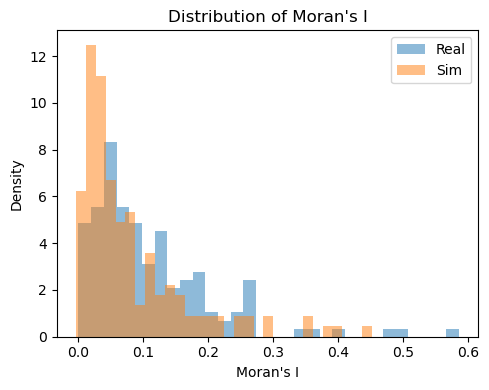

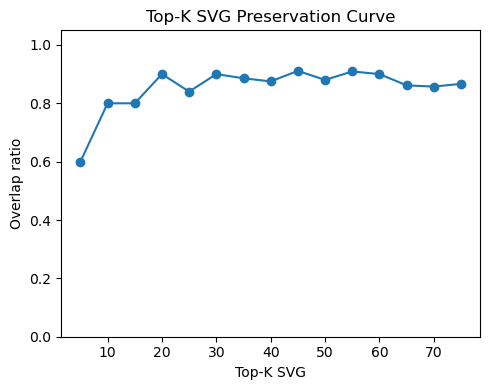

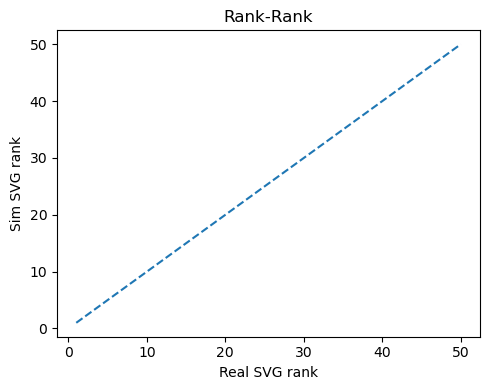

Selected SVG genes: ['Nnat', 'Mbp', 'Sln']


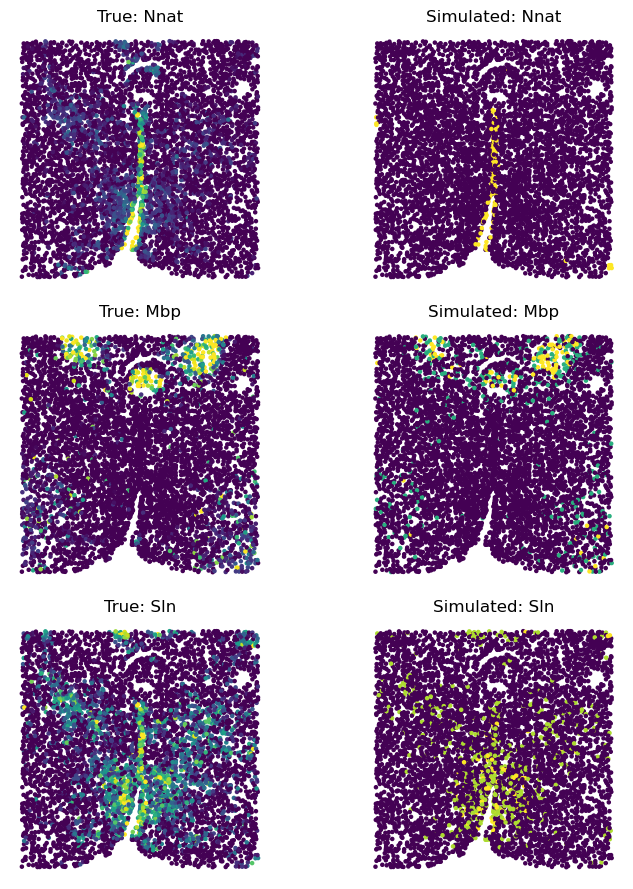

      gene  real_moran_I  sim_moran_I  real_rank  sim_rank
142   Nnat      0.586223     0.168529          1       NaN
141    Mbp      0.504370     0.376966          2       NaN
147    Sln      0.478732     0.173930          3       NaN
41    Esr1      0.397844     0.452037          4       NaN
20   Cd24a      0.352309     0.352016          5       NaN
63    Irs4      0.343976     0.356675          6       NaN
38    Ebf3      0.272444     0.402904          7       NaN
53     Gda      0.270396     0.242596          8       NaN
93    Pak3      0.265055     0.291318          9       NaN
40    Ermn      0.259933     0.292738         10       NaN


In [10]:

# ===============================
# 3.3.4 Overall evaluation: Moran's I, SVG ranking, SVG maps
# Run this cell after sim_expr has been generated.
# ===============================
from sklearn.neighbors import NearestNeighbors
from scipy.stats import rankdata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Prepare matrices
Y_true = adata_slice.layers["counts"]
if hasattr(Y_true, "toarray"):
    Y_true = Y_true.toarray()
Y_true = np.asarray(Y_true)
Y_sim = np.asarray(sim_expr)

gene_names = adata_slice.var_names.tolist()
coords = meta[["x", "y", "z"]].values.astype(float)
coords = (coords - coords.mean(axis=0)) / (coords.std(axis=0) + 1e-8)

# 2) kNN graph and Moran's I
k = 15
nn = NearestNeighbors(n_neighbors=k + 1).fit(coords)
neighbors = nn.kneighbors(coords, return_distance=False)[:, 1:]

def moran_i(x, neighbors):
    x = np.log1p(np.asarray(x, dtype=float))
    z = x - x.mean()
    denom = np.sum(z ** 2)
    if denom <= 0:
        return np.nan
    n, k = neighbors.shape
    num = np.sum(z[:, None] * z[neighbors])
    return (n / (n * k)) * num / denom

real_I = np.array([moran_i(Y_true[:, j], neighbors) for j in range(Y_true.shape[1])])
sim_I = np.array([moran_i(Y_sim[:, j], neighbors) for j in range(Y_sim.shape[1])])
valid = np.isfinite(real_I) & np.isfinite(sim_I)

# 3) Fig 3-11: distribution of Moran's I
plt.figure(figsize=(5, 4))
plt.hist(real_I[valid], bins=30, density=True, alpha=0.5, label="Real")
plt.hist(sim_I[valid], bins=30, density=True, alpha=0.5, label="Sim")
plt.xlabel("Moran's I")
plt.ylabel("Density")
plt.title("Distribution of Moran's I")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Fig 3-12(a): Top-K SVG preservation curve
real_order = np.argsort(-real_I)
sim_order = np.argsort(-sim_I)
max_k = min(75, len(gene_names))
K_list = np.arange(5, max_k + 1, 5)
overlap = []
for K in K_list:
    top_real = set(real_order[:K])
    top_sim = set(sim_order[:K])
    overlap.append(len(top_real & top_sim) / K)

plt.figure(figsize=(5, 4))
plt.plot(K_list, overlap, marker="o")
plt.xlabel("Top-K SVG")
plt.ylabel("Overlap ratio")
plt.title("Top-K SVG Preservation Curve")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# 5) Fig 3-12(b): Rank-rank plot for top SVG genes
real_rank = rankdata(-real_I, method="ordinal")
sim_rank = rankdata(-sim_I, method="ordinal")
K_rank = min(50, len(gene_names))
idx = real_order[:K_rank]

plt.figure(figsize=(5, 4))
plt.scatter(real_rank[idx], sim_rank[idx], s=18, alpha=0.7)
plt.plot([1, K_rank], [1, K_rank], linestyle="--")
plt.xlabel("Real SVG rank")
plt.ylabel("Sim SVG rank")
plt.title("Rank-Rank")
plt.tight_layout()
plt.show()

# 6) Fig 3-13: representative SVG expression maps
selected_idx = [j for j in real_order if np.isfinite(real_I[j]) and np.count_nonzero(Y_true[:, j]) >= 20][:3]
selected_genes = [gene_names[j] for j in selected_idx]
print("Selected SVG genes:", selected_genes)

x = meta["x"].values
y = meta["y"].values
fig, axes = plt.subplots(len(selected_idx), 2, figsize=(8, 3 * len(selected_idx)))
if len(selected_idx) == 1:
    axes = np.array([axes])

for r, j in enumerate(selected_idx):
    gene = gene_names[j]
    true_g = np.log1p(Y_true[:, j])
    sim_g = np.log1p(Y_sim[:, j])
    vmax = np.percentile(np.concatenate([true_g, sim_g]), 99)

    axes[r, 0].scatter(x, y, c=true_g, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[r, 0].set_title(f"True: {gene}")
    axes[r, 0].set_aspect("equal")
    axes[r, 0].axis("off")

    axes[r, 1].scatter(x, y, c=sim_g, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[r, 1].set_title(f"Simulated: {gene}")
    axes[r, 1].set_aspect("equal")
    axes[r, 1].axis("off")

plt.tight_layout()
plt.show()

# Optional: save numeric results
svg_eval = pd.DataFrame({
    "gene": gene_names,
    "real_moran_I": real_I,
    "sim_moran_I": sim_I,
    "real_rank": real_rank,
    "sim_rank": sim_rank
})
svg_eval.to_csv("svg_overall_evaluation.csv", index=False)
print(svg_eval.sort_values("real_moran_I", ascending=False).head(10))


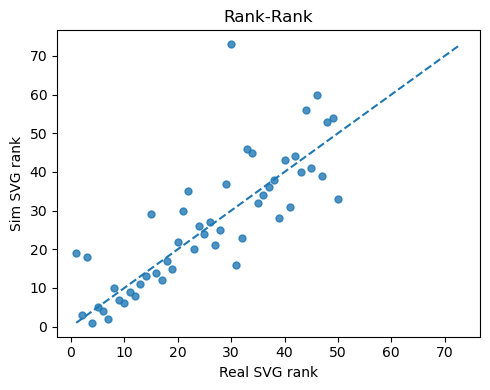

Top genes used in rank-rank plot:
['Nnat' 'Mbp' 'Sln' 'Esr1' 'Cd24a' 'Irs4' 'Ebf3' 'Gda' 'Pak3' 'Ermn' 'Pgr'
 'Gad1' 'Ar' 'Lpar1' 'Scg2' 'Prlr' 'Oprl1' 'Syt4' 'Slc18a2' 'Cckbr' 'Th'
 'Tac2' 'Slc17a6' 'Amigo2' 'Mlc1' 'Ntng1' 'Gpr165' 'Gabrg1' 'Coch' 'Cspg5'
 'Necab1' 'Sgk1' 'Aqp4' 'Ttyh2' 'Glra3' 'Calcr' 'Cyr61' 'Npy2r' 'Syt2'
 'Gjc3' 'Dgkk' 'Arhgap36' 'Pcdh11x' 'Cbln2' 'Baiap2' 'Opalin' 'Gabra1'
 'Plin3' 'Trhr' 'Sp9']


In [11]:
from scipy.stats import rankdata
import numpy as np
import matplotlib.pyplot as plt

# Keep genes with valid Moran's I in both real and simulated data
valid = np.isfinite(real_I) & np.isfinite(sim_I)

real_I_valid = real_I[valid]
sim_I_valid = sim_I[valid]
gene_names_valid = np.array(gene_names)[valid]

# Rank: smaller rank means stronger SVG
real_rank = rankdata(-real_I_valid, method="ordinal")
sim_rank = rankdata(-sim_I_valid, method="ordinal")

# Top K genes according to real Moran's I
K_rank = min(50, len(gene_names_valid))
real_order = np.argsort(-real_I_valid)
idx = real_order[:K_rank]

plt.figure(figsize=(5, 4))

# Draw diagonal first
max_rank = max(real_rank[idx].max(), sim_rank[idx].max())
plt.plot([1, max_rank], [1, max_rank], linestyle="--", zorder=1)

# Draw points on top of the line
plt.scatter(
    real_rank[idx],
    sim_rank[idx],
    s=25,
    alpha=0.8,
    zorder=2
)

plt.xlabel("Real SVG rank")
plt.ylabel("Sim SVG rank")
plt.title("Rank-Rank")
plt.tight_layout()
plt.show()

print("Top genes used in rank-rank plot:")
print(gene_names_valid[idx])

## All slices for fitting and simulation